# Set-up

In [1]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme, extract_loci

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [3]:
os.chdir('/cellar/users/aklie/projects/igvf/ChromBetaNet')

In [4]:
path_out = "scratch/2025_06_22"

In [5]:
dtype = torch.float64

seq_len = 2114
target_len = 1000
mut_window = 500
plot_window = 200

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - mut_window // 2
seq_end = seq_center + mut_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - mut_window // 2
target_end = target_center + mut_window // 2

# Plot starts
plot_seq_center = 1050
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 807, seq_end: 1307
target_start: 250, target_end: 750
plot_seq_start: 957, plot_seq_end: 1157
plot_target_start: 400, plot_target_end: 600


# Load genome

In [6]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [7]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [8]:
path_peaks = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/peaks/D15_merged_ENP_peaks.bed"
path_schema = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/3-cyt_rna_celltype/snapatac2/SC.beta.narrowPeak.schema"
schema = pd.read_csv(path_schema, header=None, sep='\t')[0].tolist()  # convert schema to a list
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=schema)  # corrected to use schema

In [9]:
# Remove duplicate chrom start and end taking the highest q_value
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
7,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193
109643,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150
6,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142
3021,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661
112224,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146
...,...,...,...,...,...,...,...,...,...,...
125611,chr18,78739087,78739330,.,13,.,1.479915,2.706340,1.309857,94
108848,chr17,17019608,17019854,.,13,.,1.675393,2.705390,1.308933,129
119139,chr18,7063745,7064068,.,13,.,1.617133,2.703760,1.307358,73
267882,chr8,144538109,144538392,.,13,.,1.732673,2.701570,1.305214,185


# Load motifs

In [10]:
motifs = read_meme("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")
motif_names = np.array(list(motifs.keys()))

In [11]:
tmp = pd.read_csv("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/tfs_initial.txt", header=None, sep='\t', names=["motif_id", "annotated_tf", "evalue"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]
motif_id_mp

motif_id
Average_34                       ZN143_MOUSE.H11MO.0.A
Average_15                               CTCF_MA0139.1
Average_23                        NFYB_HUMAN.H11MO.0.A
Average_30                              HNF4G_MA0484.1
Average_18                        NRF1_HUMAN.H11MO.0.A
Average_39                        MAFB_HUMAN.H11MO.0.B
Average_38                        NDF2_MOUSE.H11MO.0.A
Average_27                         SP2_HUMAN.H11MO.0.A
D15_ENP.counts.pattern_32.pfm               ETV6_ETS_1
Average_14                              HNF1B_MA0153.2
Average_16                        TYY1_HUMAN.H11MO.0.A
Average_32                       FOXA2_HUMAN.H11MO.0.A
Average_40                        ELK1_HUMAN.H11MO.0.B
Average_6                         TAL1_HUMAN.H11MO.0.A
Average_42                        RFX6_MOUSE.H11MO.0.C
Average_35                           JUN+JUNB_MA1133.1
Average_25                                ARNTL_bHLH_1
Average_22                             ZBTB33_MA0527.1
A

# Load model

In [12]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [13]:
count_wrapper = CountWrapper(model).cuda().eval()

# Original sequence

In [14]:
# 
chrom = "chr4"
start = 84432784
end = 84434897

In [15]:
original_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTGGTGAAAACAATCTGAGGAGAACAAGGGCTCTGTTTTTTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()
len(original_seq)

2114

In [16]:
# Get the sequence corresponding to the region of interest from the genome fasta
seq = genome[chrom][start-1:end].seq.upper()
seq

'AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATGAGGTGAGGGCAAGATGGAGGTGGGGTGGAGGCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGAT

In [17]:
seq == original_seq

True

In [18]:
# Get predictions
original_seq_onehot = np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_profile, original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())
original_pred = original_counts * original_profile
print(f"original counts: {original_counts}")

original counts: 325.5494689941406


In [19]:
# Get attribution scores for the original sequence
X_attr = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr.shape

100%|██████████| 20/20 [00:18<00:00,  1.10it/s]


torch.Size([1, 4, 2114])

In [20]:
seqlets = recursive_seqlets(X_attr[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(original_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [21]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,MEOX2_MA0706.1,954,969,0.052564,3.774758e-15
1,RFX6_MOUSE.H11MO.0.C,1231,1250,0.566003,1.538462e-02
2,HNF6_HUMAN.H11MO.0.B,971,986,0.465164,2.121212e-02


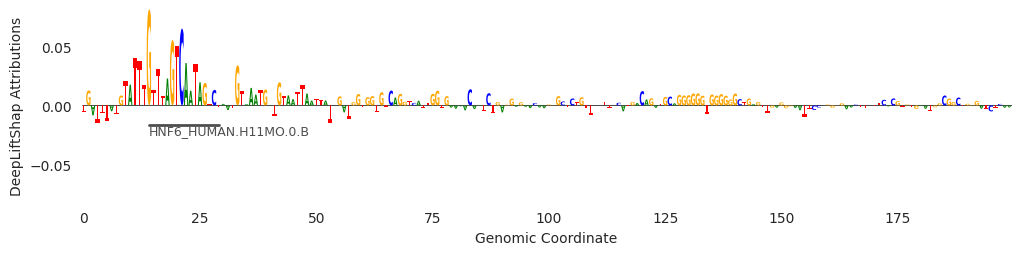

In [22]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

In [23]:
wild_type_enhancer_counts = np.log(original_counts)

# Mutated sequence

In [24]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [25]:
mutated_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTTGTGTAAACAATCTGAGGTAAACAAGGGCTCTGTTTACTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()

In [26]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(1032, 'G', 'T'),
 (1036, 'A', 'T'),
 (1050, 'A', 'T'),
 (1051, 'G', 'A'),
 (1068, 'T', 'A'),
 (1069, 'T', 'C')]

In [27]:
# add left flank and right flank to mutated sequence
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
mutated_pred = mutated_counts * mutated_profile
print(f"mutated counts: {mutated_counts}")

mutated counts: 1001.6312866210938


In [34]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=4,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 26.19it/s]


torch.Size([1, 4, 2114])

In [35]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [36]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,MEOX2_MA0706.1,954,968,0.012949,1.221245e-15
1,HNF6_HUMAN.H11MO.0.B,971,986,0.507922,4.996004e-15
2,RFX6_MOUSE.H11MO.0.C,1232,1246,0.427554,2.557545e-03
3,FOXA2_HUMAN.H11MO.0.A,1044,1059,0.403301,2.290076e-02
4,FOXA2_HUMAN.H11MO.0.A,1030,1045,0.436668,3.562341e-02


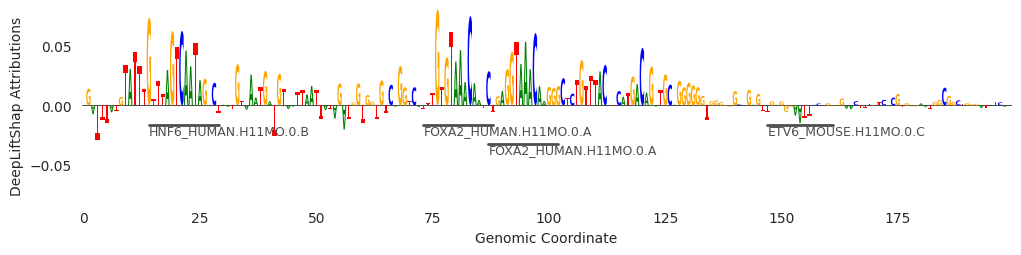

In [37]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

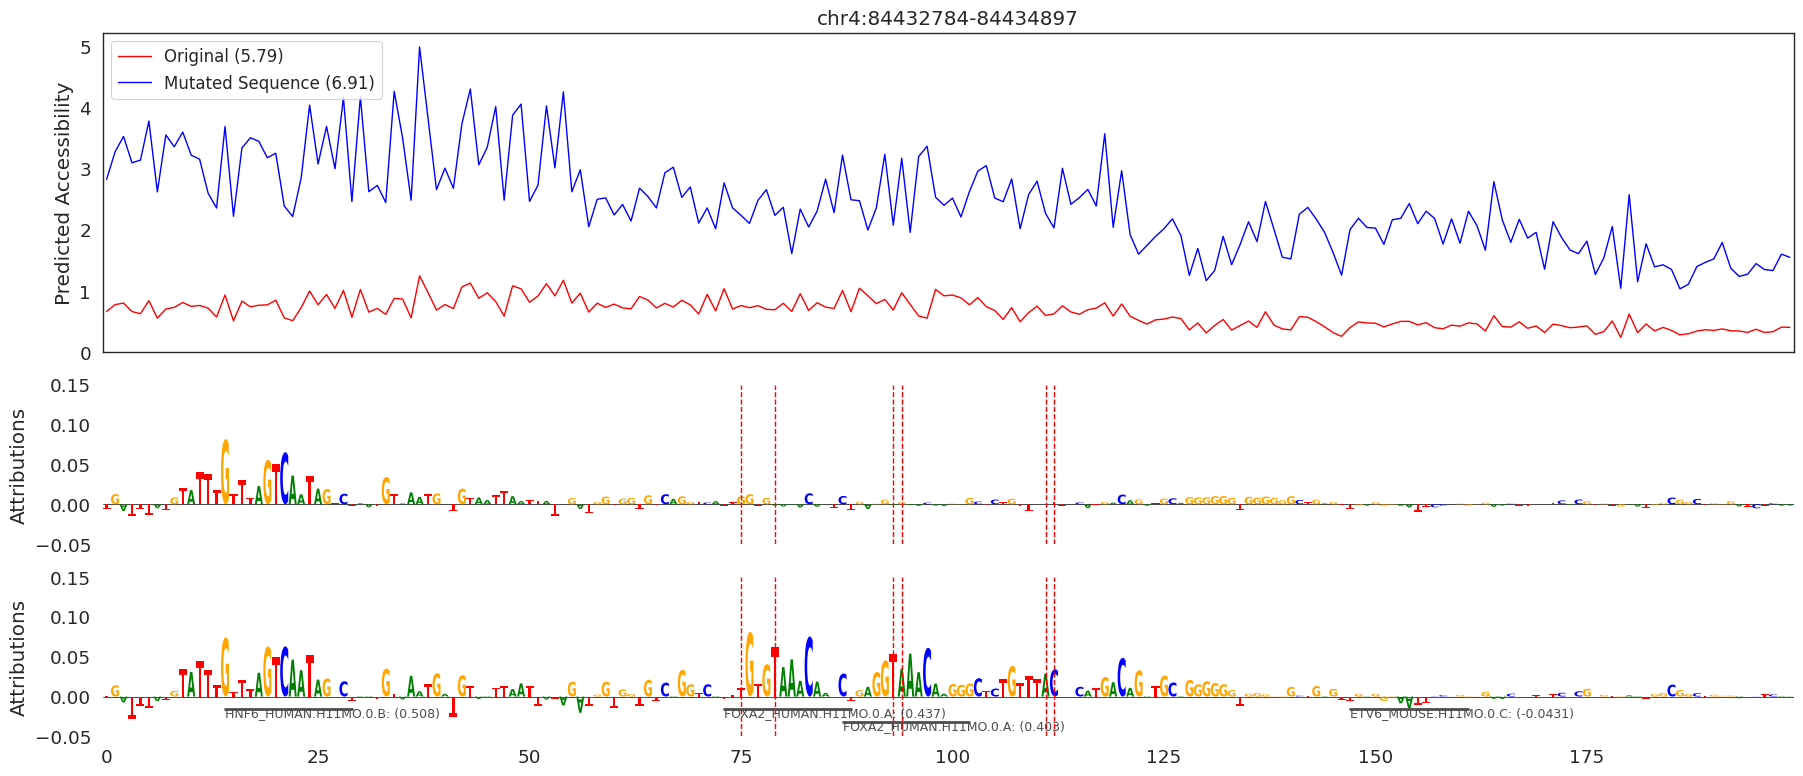

In [ ]:
offset = 0

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"NKX61_validated_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [39]:
validated_mutated_enhancer_counts = np.log(mutated_counts)

# Get baseline level of predictions

In [41]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [42]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=["/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw"],
    chroms=["chr4"]
)

In [43]:
y_0 = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

100%|██████████| 344/344 [00:13<00:00, 26.42it/s]


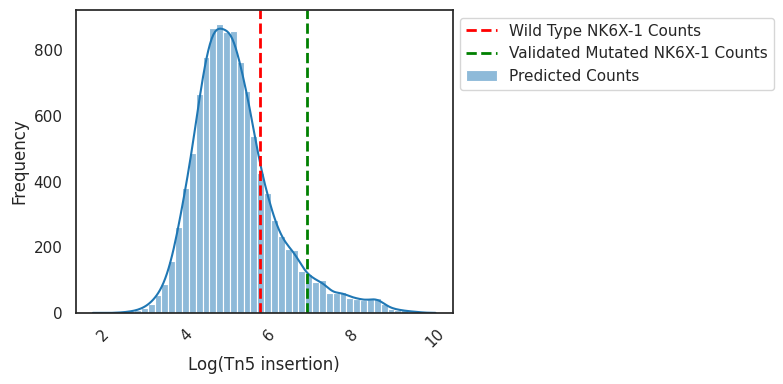

In [ ]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        y_0,
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot NKX6-1 Enhancer Original as vertical line
    ax.axvline(x=wild_type_enhancer_counts, color='red', linestyle='--', linewidth=2, label='Wild Type NK6X-1 Counts')
    
    # Plot NKX6-1 Enhancer Mutated as vertical line
    ax.axvline(x=validated_mutated_enhancer_counts, color='green', linestyle='--', linewidth=2, label='Validated Mutated NK6X-1 Counts')

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# ISM

In [45]:
import sys
sys.path.append(path_out)
from utils import greedy_ism

In [46]:
ism_window = 500

## Maximize predictions

In [47]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [48]:
X_ = torch.tensor(original_seq_onehot)

In [49]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 5.786
Iteration 1/10 - y_hat: 6.346
Iteration 2/10 - y_hat: 6.820
Iteration 3/10 - y_hat: 7.245
Iteration 4/10 - y_hat: 7.620
Iteration 5/10 - y_hat: 7.937
Iteration 6/10 - y_hat: 8.273
Iteration 7/10 - y_hat: 8.530
Iteration 8/10 - y_hat: 8.803
Iteration 9/10 - y_hat: 9.052
Iteration 10/10 - y_hat: 9.238


In [50]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:23<00:00,  1.19s/it]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

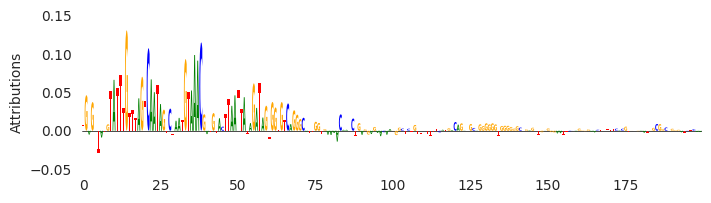

In [56]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [57]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(910, 'T', 'A'),
 (925, 'T', 'G'),
 (960, 'T', 'G'),
 (995, 'T', 'C'),
 (1002, 'A', 'C'),
 (1015, 'G', 'A'),
 (1027, 'T', 'G'),
 (1246, 'A', 'G'),
 (1275, 'G', 'A'),
 (1287, 'G', 'T')]

In [58]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 10268.461057155857


((1000,), (1000,))

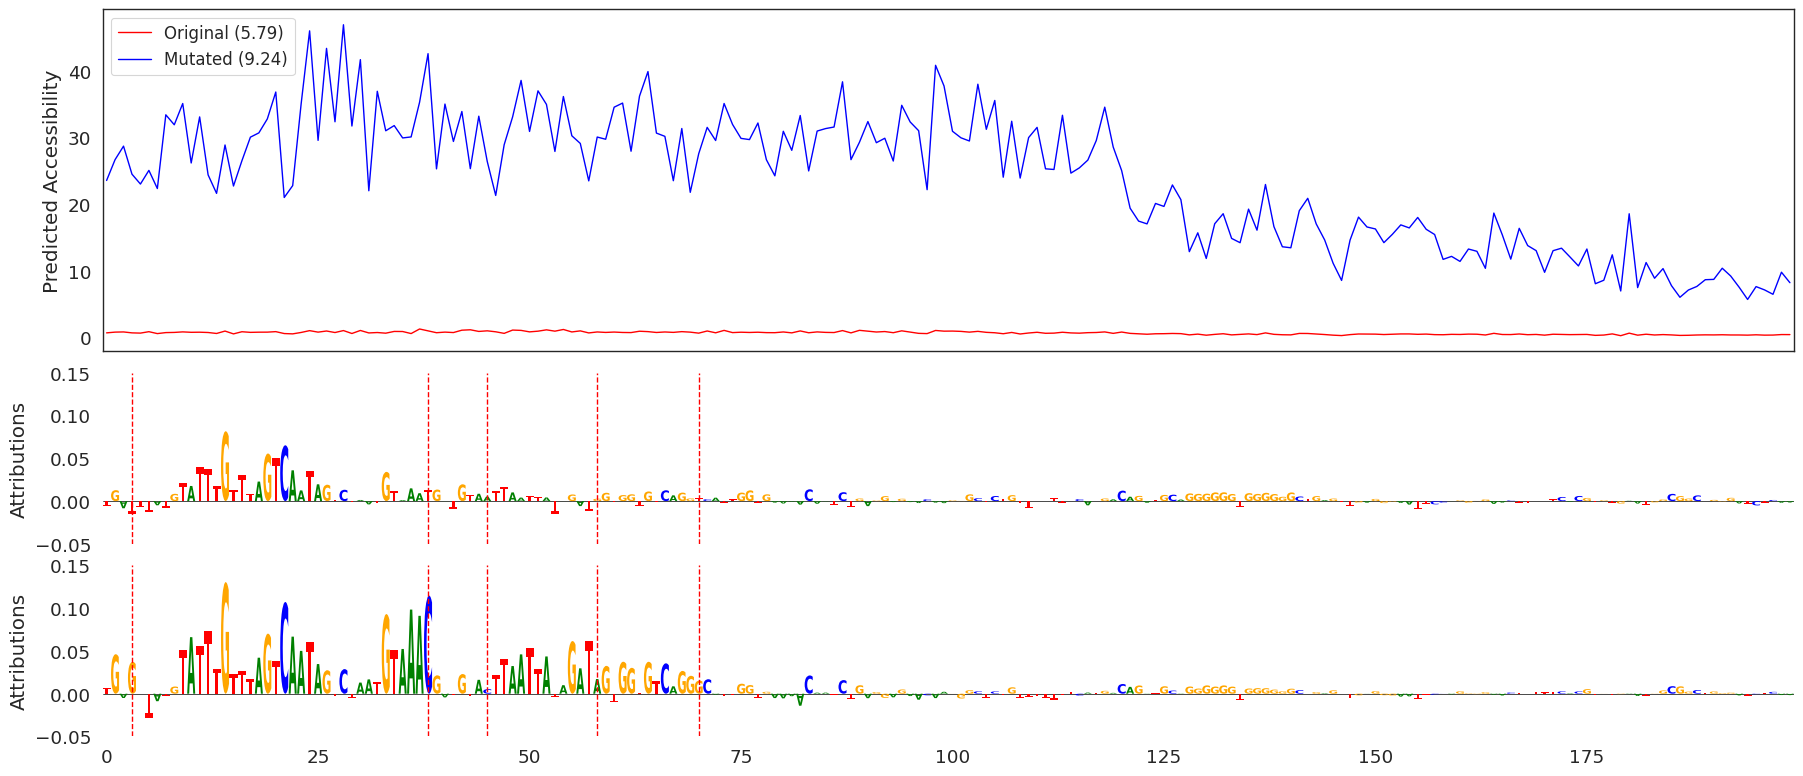

In [59]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [60]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [61]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,RFX6_MOUSE.H11MO.0.C,1232,1250,0.800946,0.005333
1,FOXA2_HUMAN.H11MO.0.A,985,1001,0.603320,0.010667
2,HNF6_HUMAN.H11MO.0.B,971,986,0.719247,0.023747
3,FOXA2_HUMAN.H11MO.0.A,963,977,0.581777,0.039474


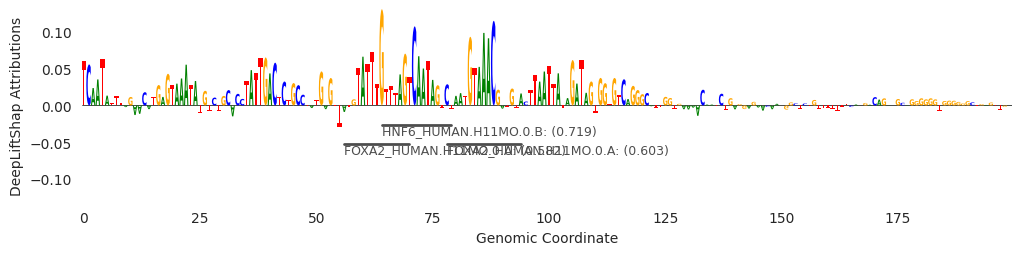

In [62]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

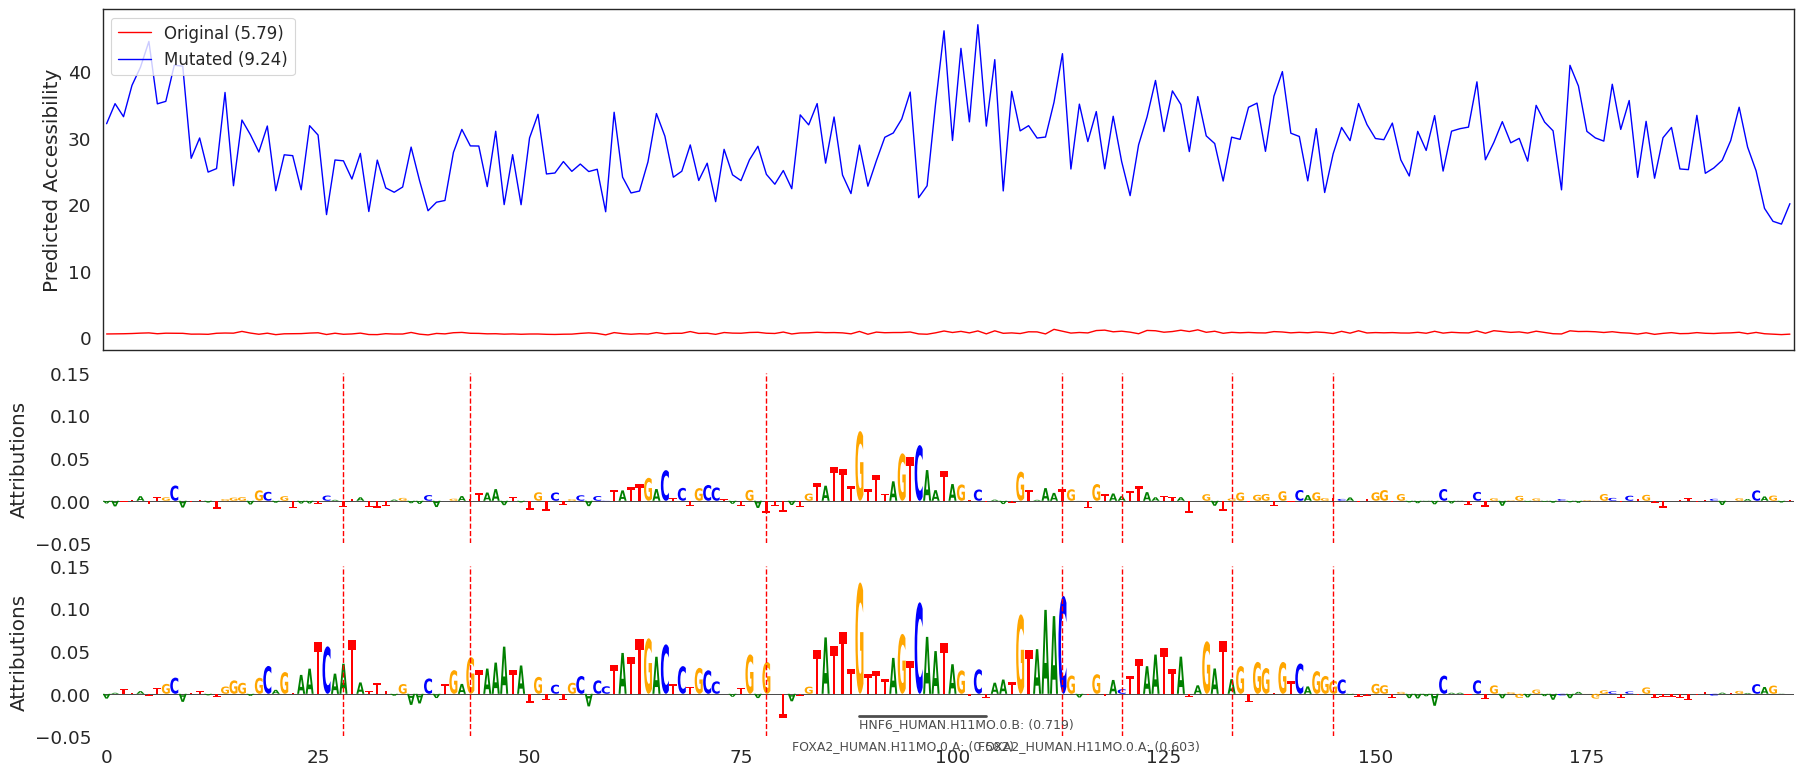

In [ ]:
offset = -75

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"NKX61_full_ism_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [65]:
maximum_counts = np.log(mutated_counts)

## Try to match the validated one

In [67]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [68]:
X_ = torch.tensor(original_seq_onehot)

In [69]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=3,
    verbose=True,
)

Iteration 0/3 - y_hat: 5.786
Iteration 1/3 - y_hat: 6.346
Iteration 2/3 - y_hat: 6.820
Iteration 3/3 - y_hat: 7.245


In [70]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.49it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

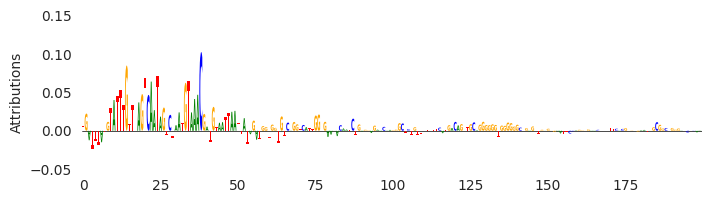

In [71]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [72]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(910, 'T', 'A'), (925, 'T', 'G'), (995, 'T', 'C')]

In [73]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 1399.8463915583554


((1000,), (1000,))

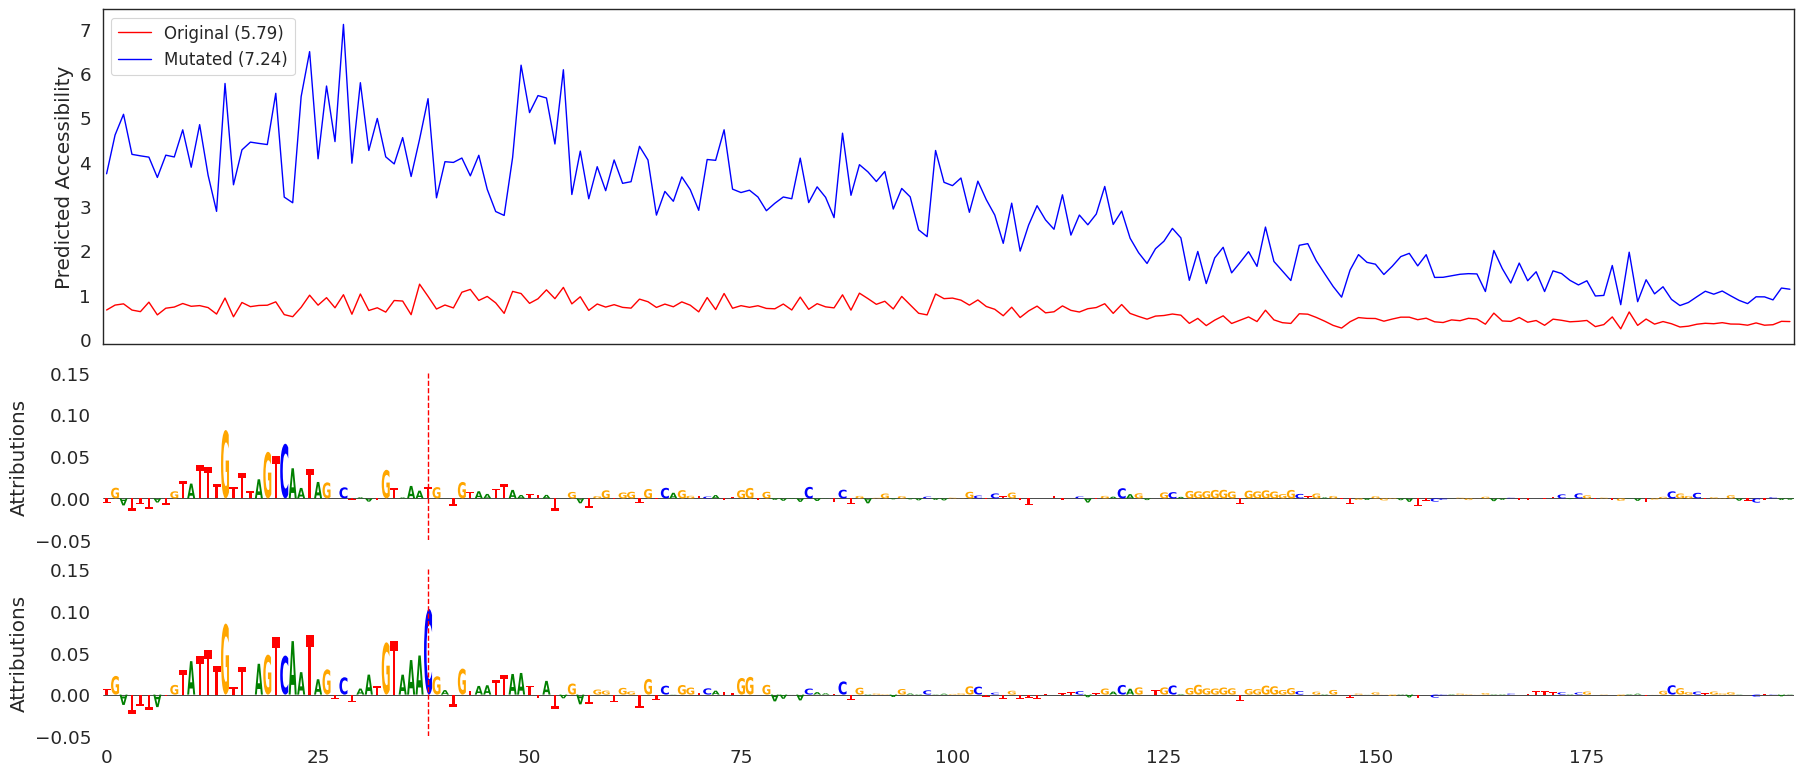

In [74]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [75]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [76]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,HNF6_HUMAN.H11MO.0.B,902,916,0.400991,0.002525
1,MEOX2_MA0706.1,954,969,0.082840,0.010000
2,RFX6_MOUSE.H11MO.0.C,1233,1247,0.417935,0.017632
3,HNF6_HUMAN.H11MO.0.B,971,986,0.552916,0.020151
4,FOXA2_HUMAN.H11MO.0.A,987,1001,0.430969,0.030227


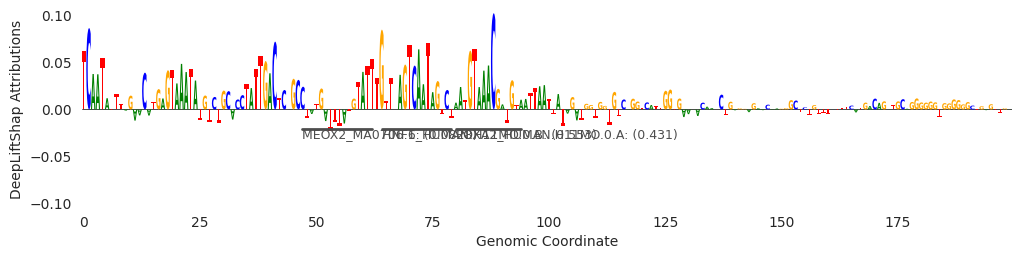

In [77]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

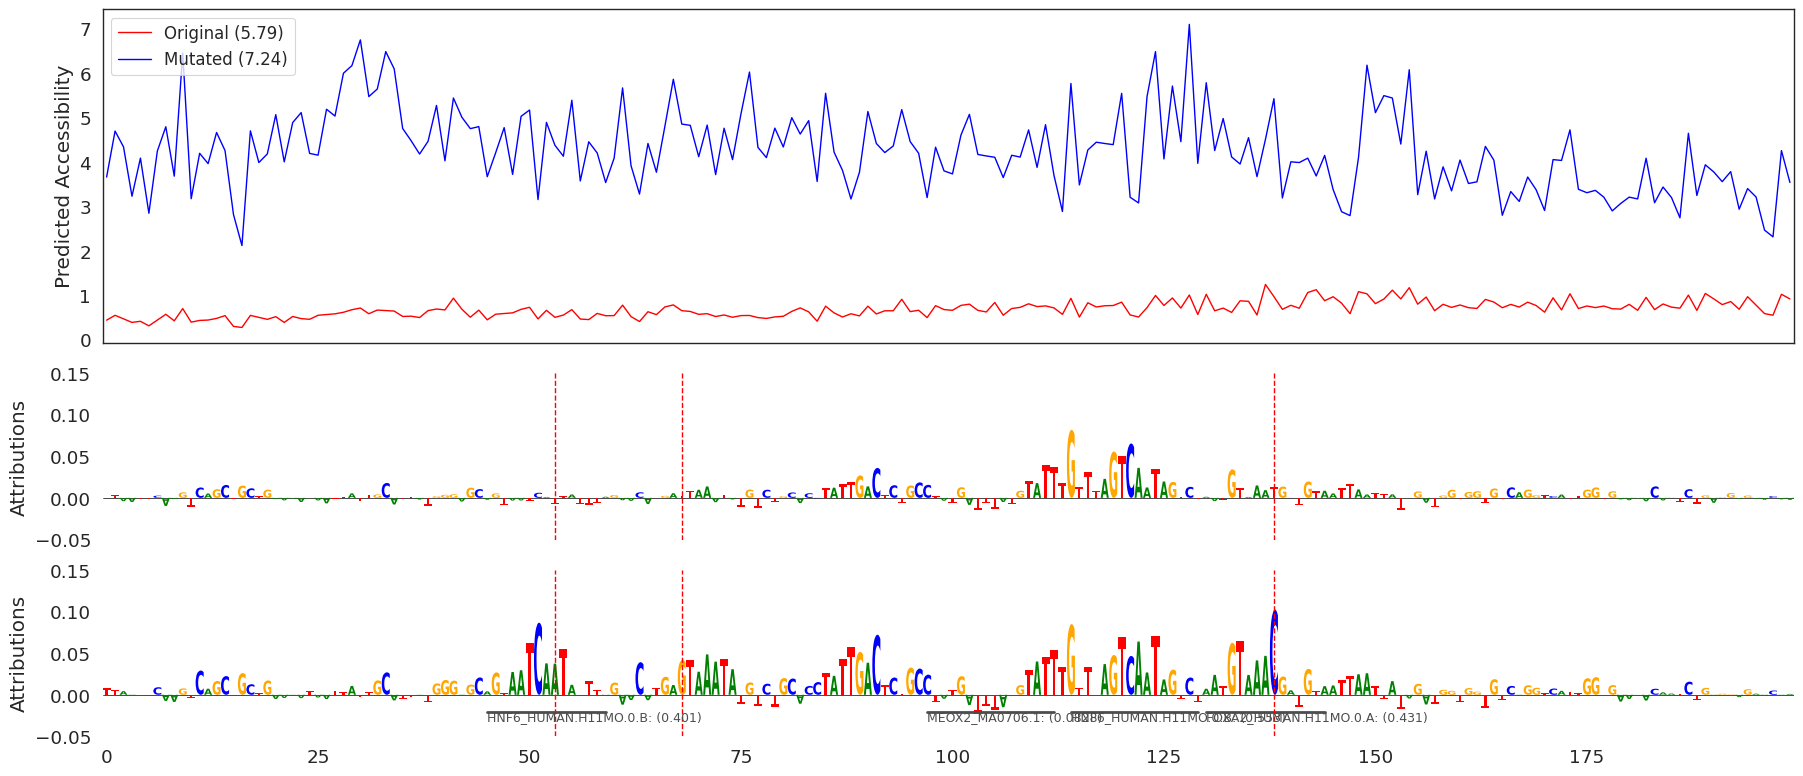

In [78]:
offset = -100

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"NKX61_ism_3_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [79]:
matched_preds = np.log(mutated_counts)

## Kinda maximize

In [155]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [156]:
X_ = torch.tensor(original_seq_onehot)

In [157]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=6,
    verbose=True,
)

Iteration 0/6 - y_hat: 5.786
Iteration 1/6 - y_hat: 6.346
Iteration 2/6 - y_hat: 6.820
Iteration 3/6 - y_hat: 7.245
Iteration 4/6 - y_hat: 7.620
Iteration 5/6 - y_hat: 7.937
Iteration 6/6 - y_hat: 8.273


In [158]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.74it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

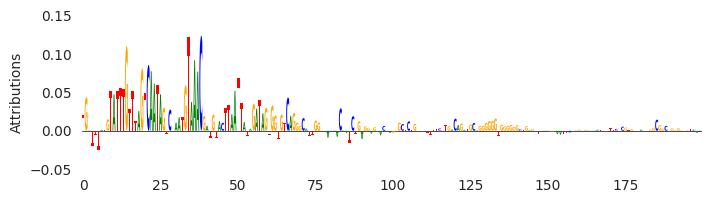

In [159]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [160]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(910, 'T', 'A'),
 (925, 'T', 'G'),
 (995, 'T', 'C'),
 (1002, 'A', 'C'),
 (1015, 'G', 'A'),
 (1027, 'T', 'G')]

In [161]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 3911.9550892806283


((1000,), (1000,))

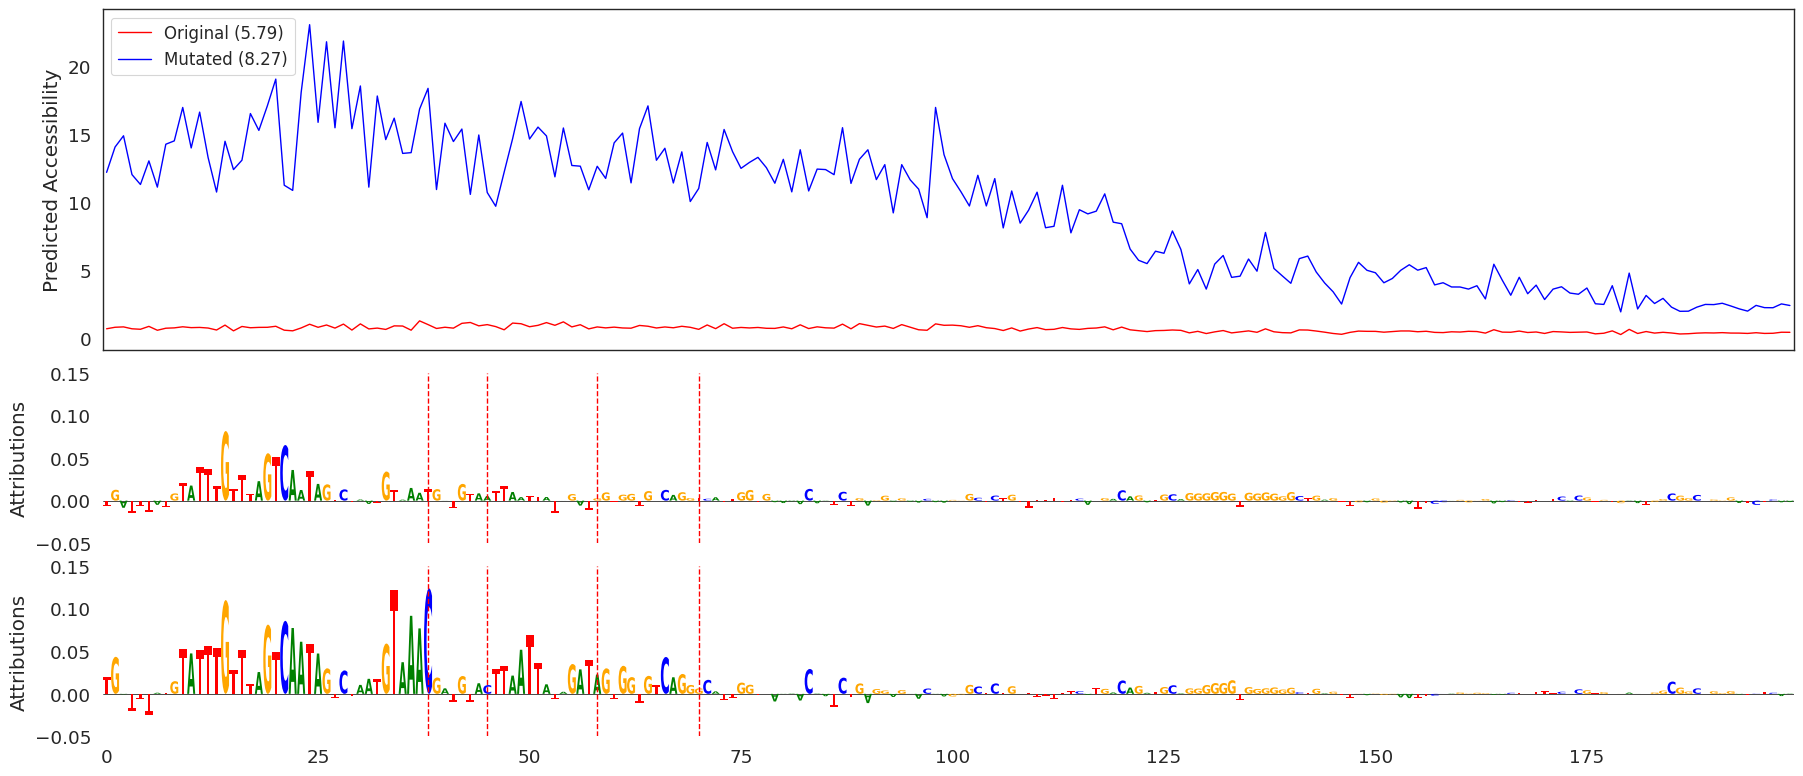

In [162]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [163]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [164]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,MEOX2_MA0706.1,954,968,0.147317,2.442491e-15
1,FOXA2_HUMAN.H11MO.0.A,986,1001,0.581339,2.710027e-03
2,HNF6_HUMAN.H11MO.0.B,971,987,0.739196,1.084011e-02
3,FOXA2_HUMAN.H11MO.0.A,963,978,0.636921,2.894737e-02


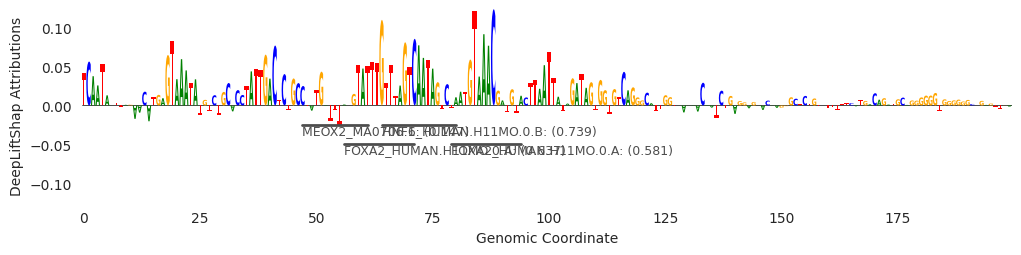

In [165]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

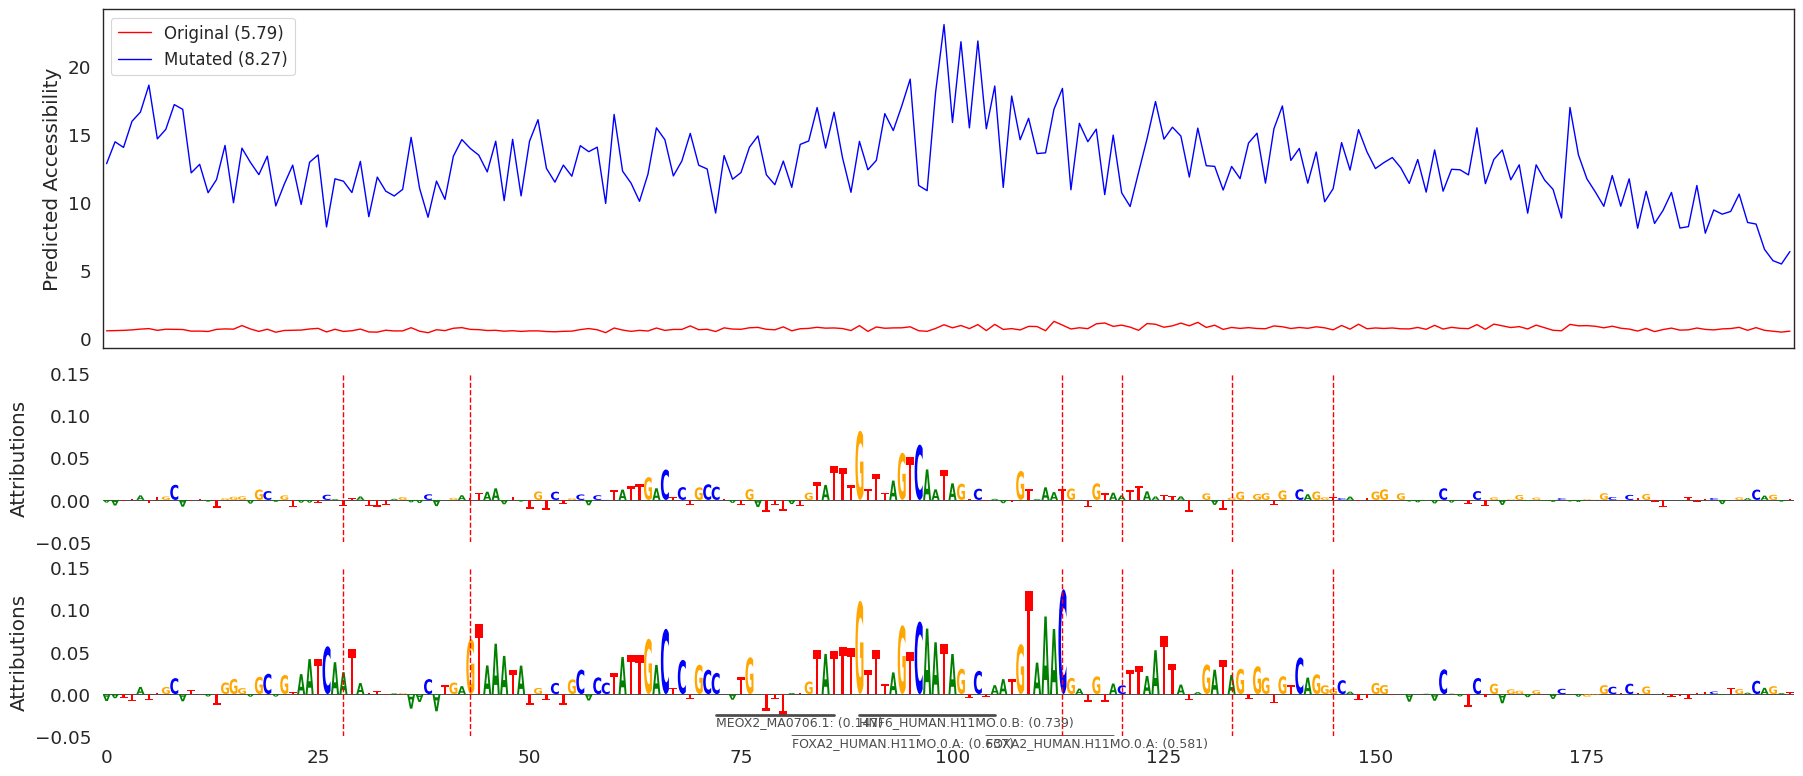

In [166]:
offset = -75

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"NKX61_ism_6_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [167]:
kinda_maximize_preds = np.log(mutated_counts)

## Minimize predictions

In [93]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [94]:
X_ = torch.tensor(original_seq_onehot)

In [95]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
    mode="minimize"
)

Iteration 0/10 - y_hat: 5.786
Iteration 1/10 - y_hat: 5.137
Iteration 2/10 - y_hat: 4.138
Iteration 3/10 - y_hat: 3.775
Iteration 4/10 - y_hat: 3.642
Iteration 5/10 - y_hat: 3.497
Iteration 6/10 - y_hat: 3.339
Iteration 7/10 - y_hat: 3.186
Iteration 8/10 - y_hat: 3.075
Iteration 9/10 - y_hat: 2.973
Iteration 10/10 - y_hat: 2.878


In [96]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.51it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

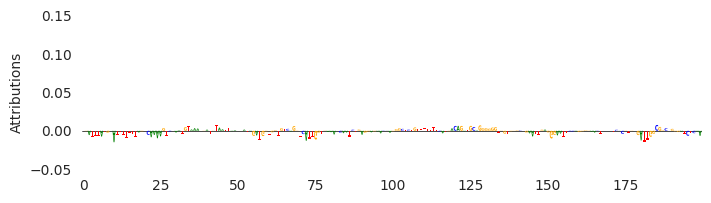

In [97]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [98]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(871, 'C', 'T'),
 (927, 'A', 'G'),
 (971, 'G', 'T'),
 (981, 'T', 'A'),
 (1094, 'G', 'T'),
 (1102, 'G', 'A'),
 (1138, 'A', 'T'),
 (1238, 'T', 'A'),
 (1278, 'A', 'C'),
 (1299, 'C', 'A')]

In [99]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 17.78521683654083


((1000,), (1000,))

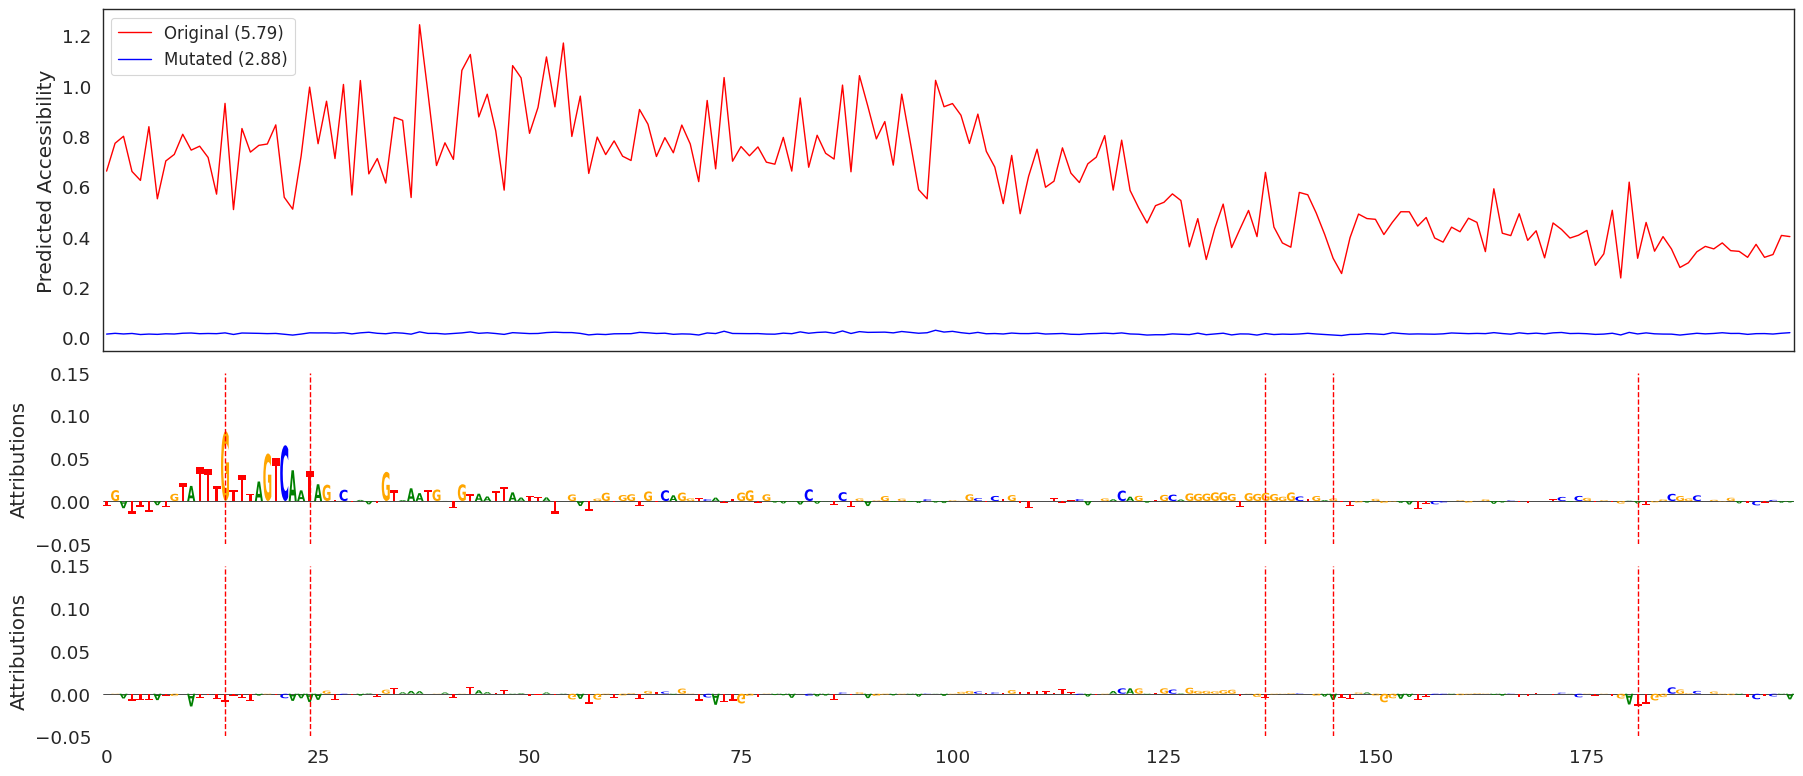

In [100]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [101]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [102]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,NFYB_HUMAN.H11MO.0.A,1131,1145,-0.052874,0.003425
1,JUN+JUNB_MA1133.1,1022,1038,-0.054833,0.017182
2,HNF6_HUMAN.H11MO.0.B,940,956,0.053669,0.024510
3,HNF4G_MA0484.1,1273,1287,-0.039142,0.034364


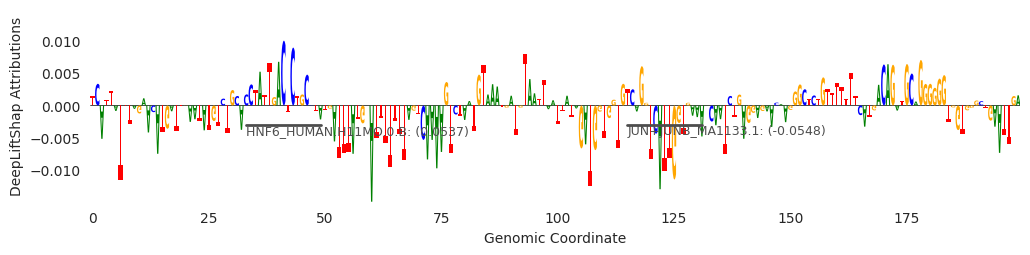

In [103]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

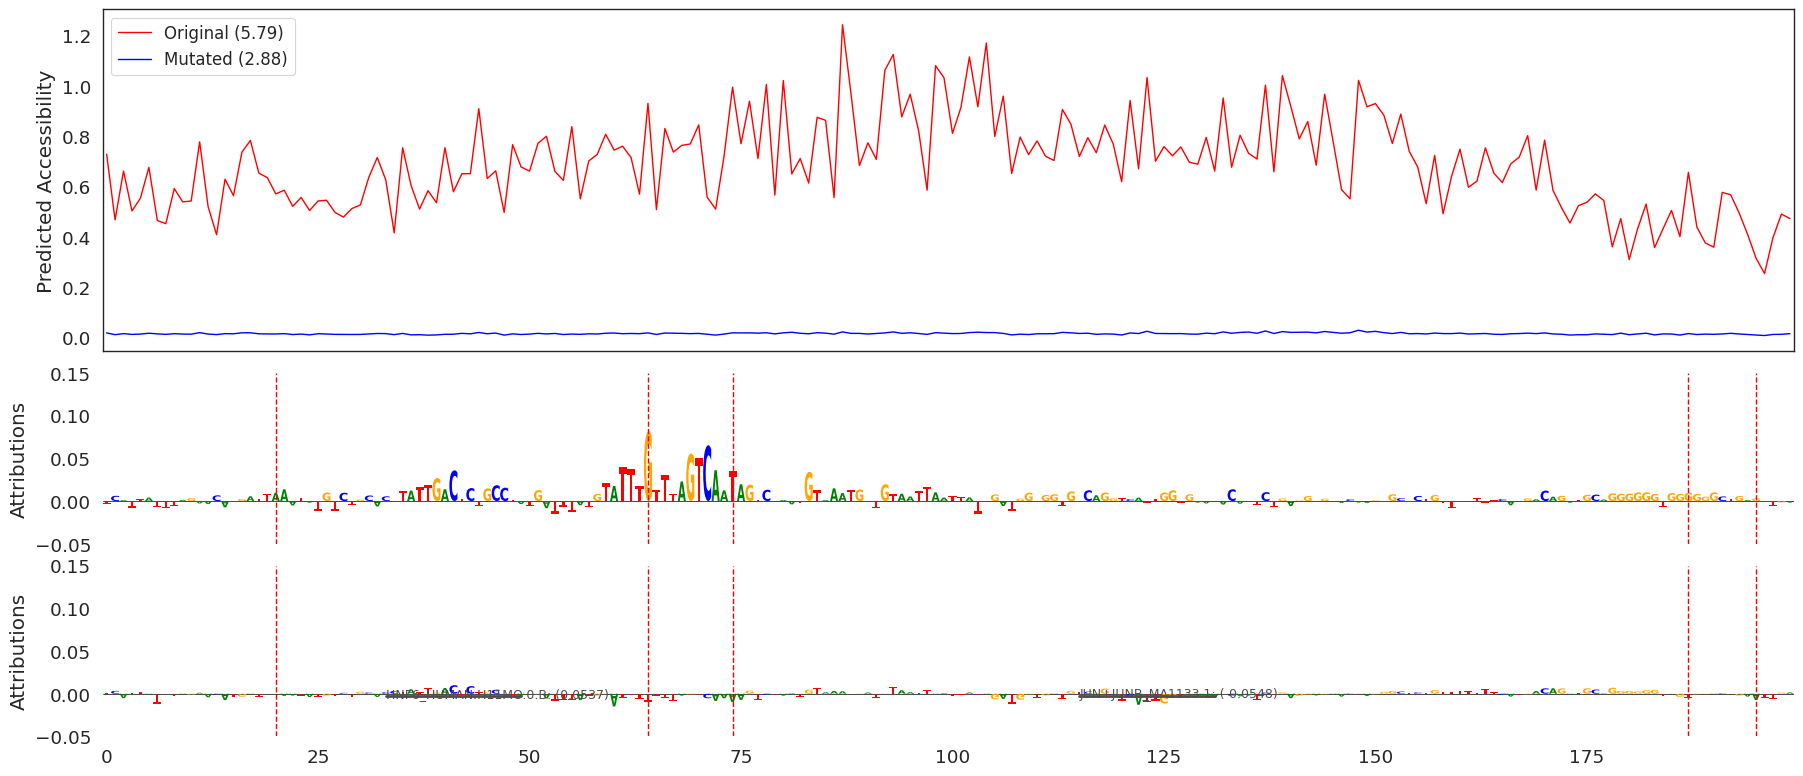

In [104]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"NKX61_ism_min_10_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [105]:
minimize_preds = np.log(mutated_counts)

## Somewhat minimize predictions

In [132]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [133]:
X_ = torch.tensor(original_seq_onehot)

In [134]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=3,
    verbose=True,
    mode="minimize"
)

Iteration 0/3 - y_hat: 5.786
Iteration 1/3 - y_hat: 5.137
Iteration 2/3 - y_hat: 4.138
Iteration 3/3 - y_hat: 3.775


In [135]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.66it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

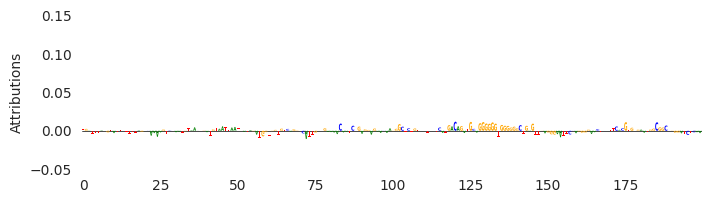

In [136]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [137]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(971, 'G', 'T'), (981, 'T', 'A'), (1238, 'T', 'A')]

In [138]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 43.572800607472516


((1000,), (1000,))

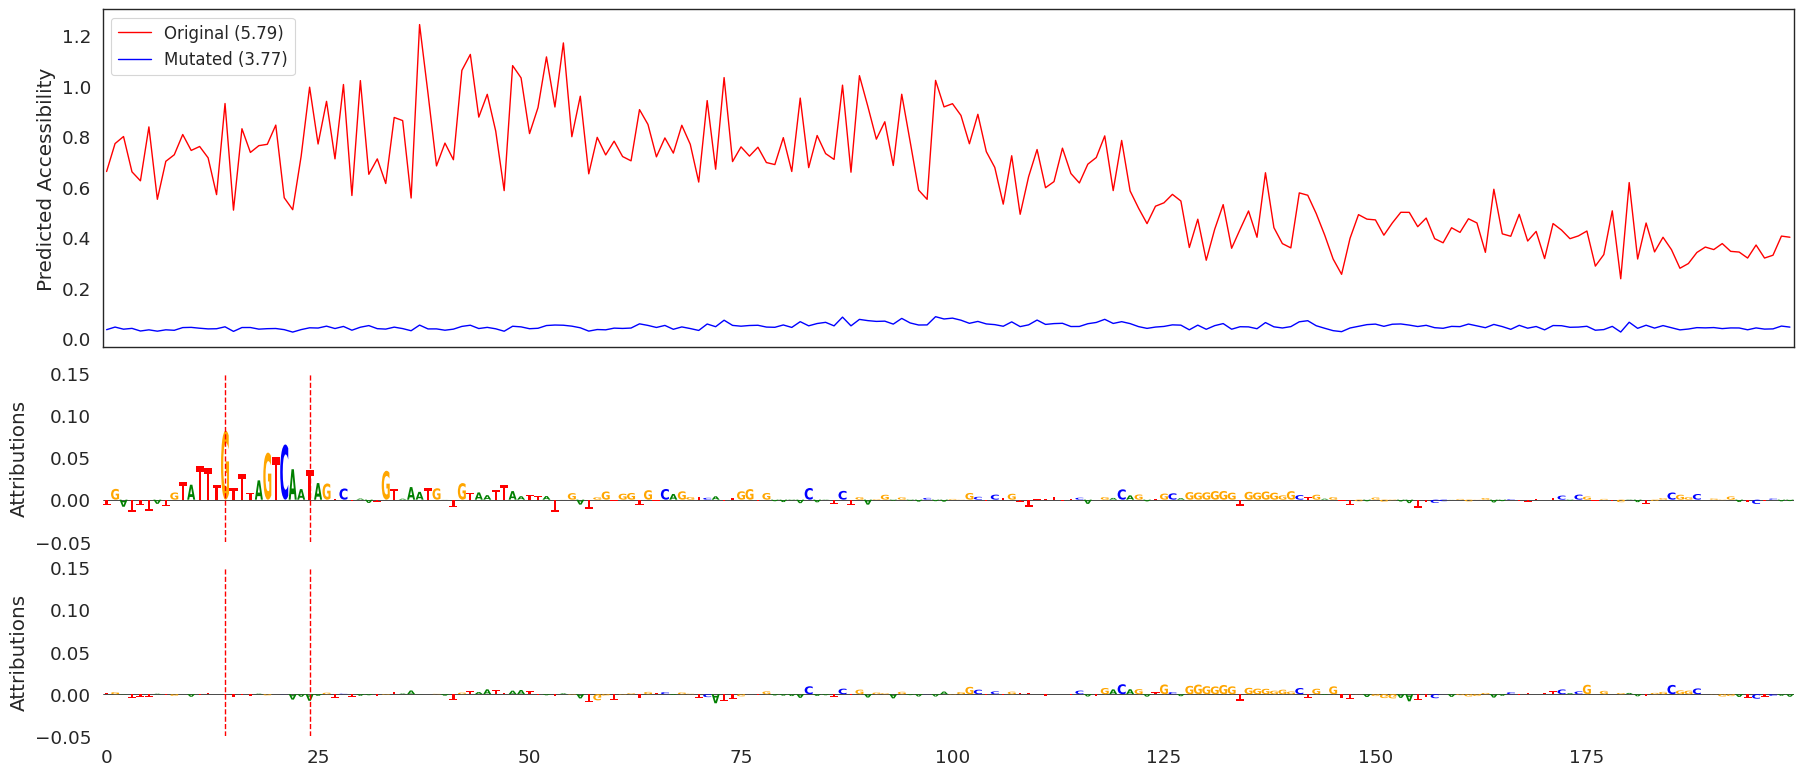

In [139]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [140]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [141]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,NDF2_MOUSE.H11MO.0.A,1280,1297,0.095868,0.010033
1,SP2_HUMAN.H11MO.0.A,1080,1094,0.077491,0.016556
2,JUN+JUNB_MA1133.1,1022,1036,-0.026460,0.020619
3,NDF2_MOUSE.H11MO.0.A,865,879,0.063354,0.029801
4,ETV6_MOUSE.H11MO.0.C,1104,1118,-0.053925,0.040816


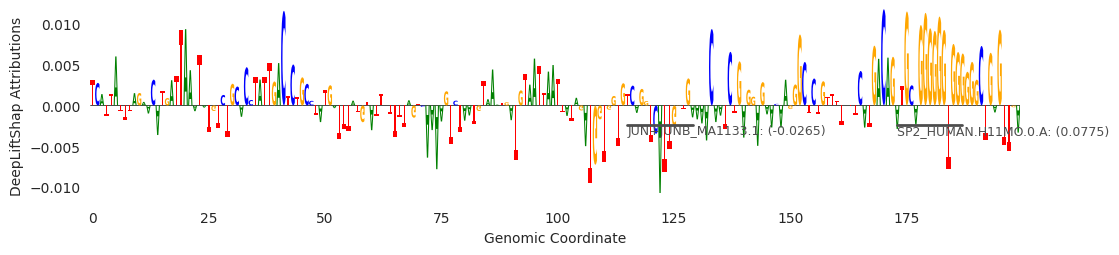

In [142]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

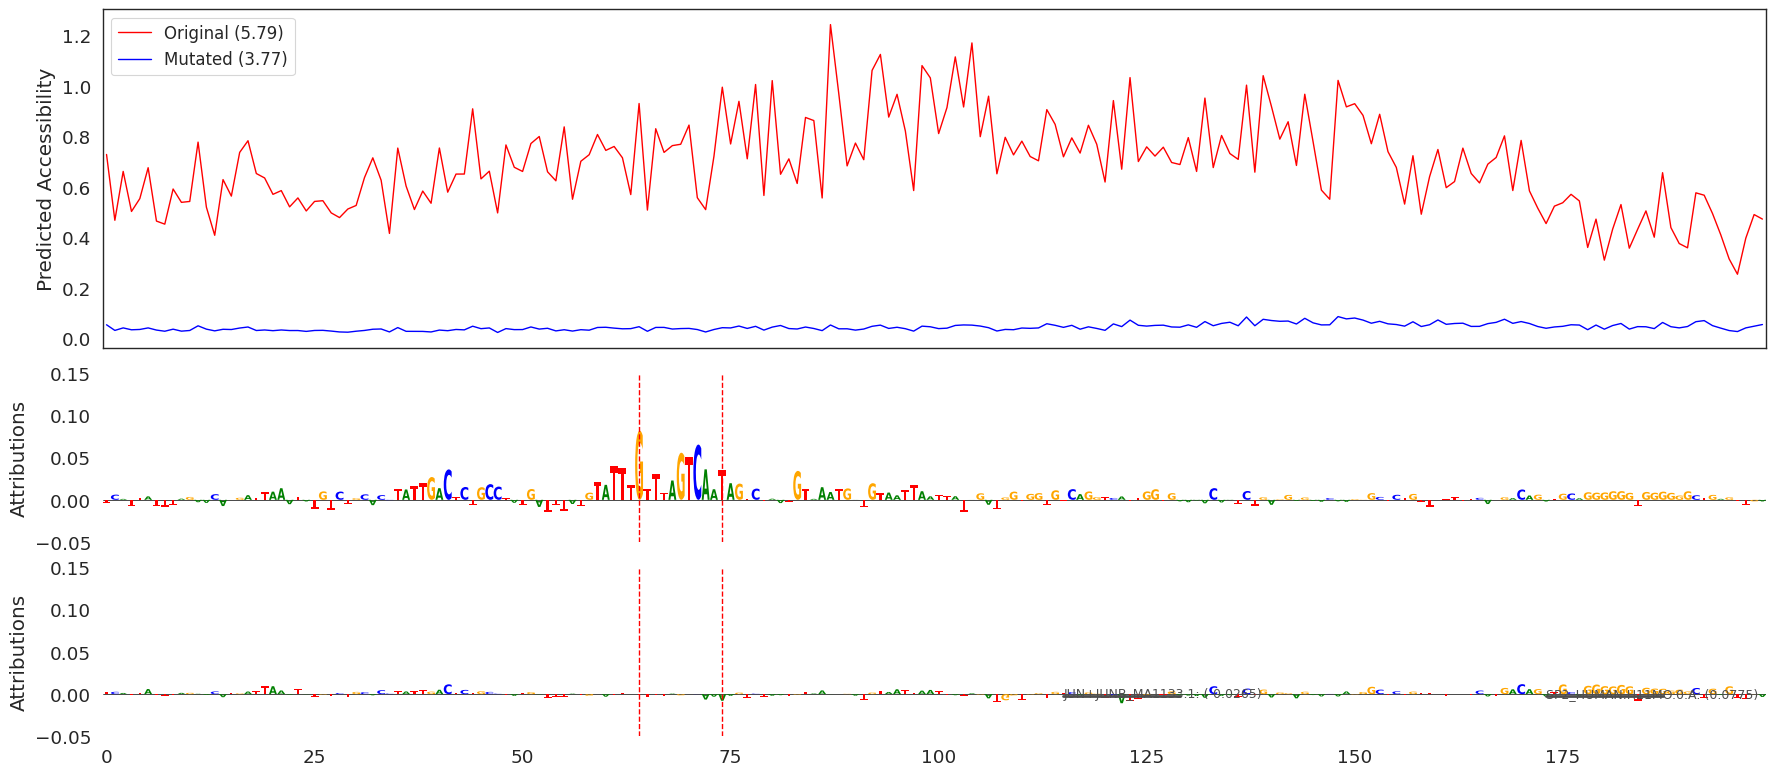

In [143]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"NKX61_ism_min_3_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [144]:
somewhat_minimize_preds = np.log(mutated_counts)

## kinda minimize predictions

In [169]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [170]:
X_ = torch.tensor(original_seq_onehot)

In [171]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=1,
    verbose=True,
    mode="minimize"
)

Iteration 0/1 - y_hat: 5.786
Iteration 1/1 - y_hat: 5.137


In [172]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.71it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

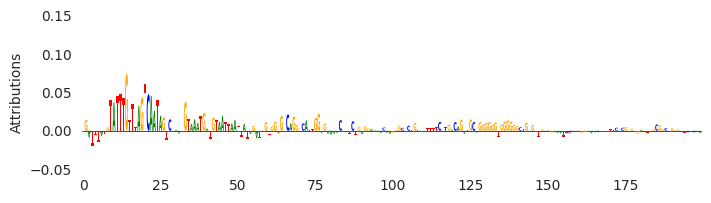

In [173]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [174]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(1238, 'T', 'A')]

In [175]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 325.40500771867727
mutated counts: 170.2505817509003


((1000,), (1000,))

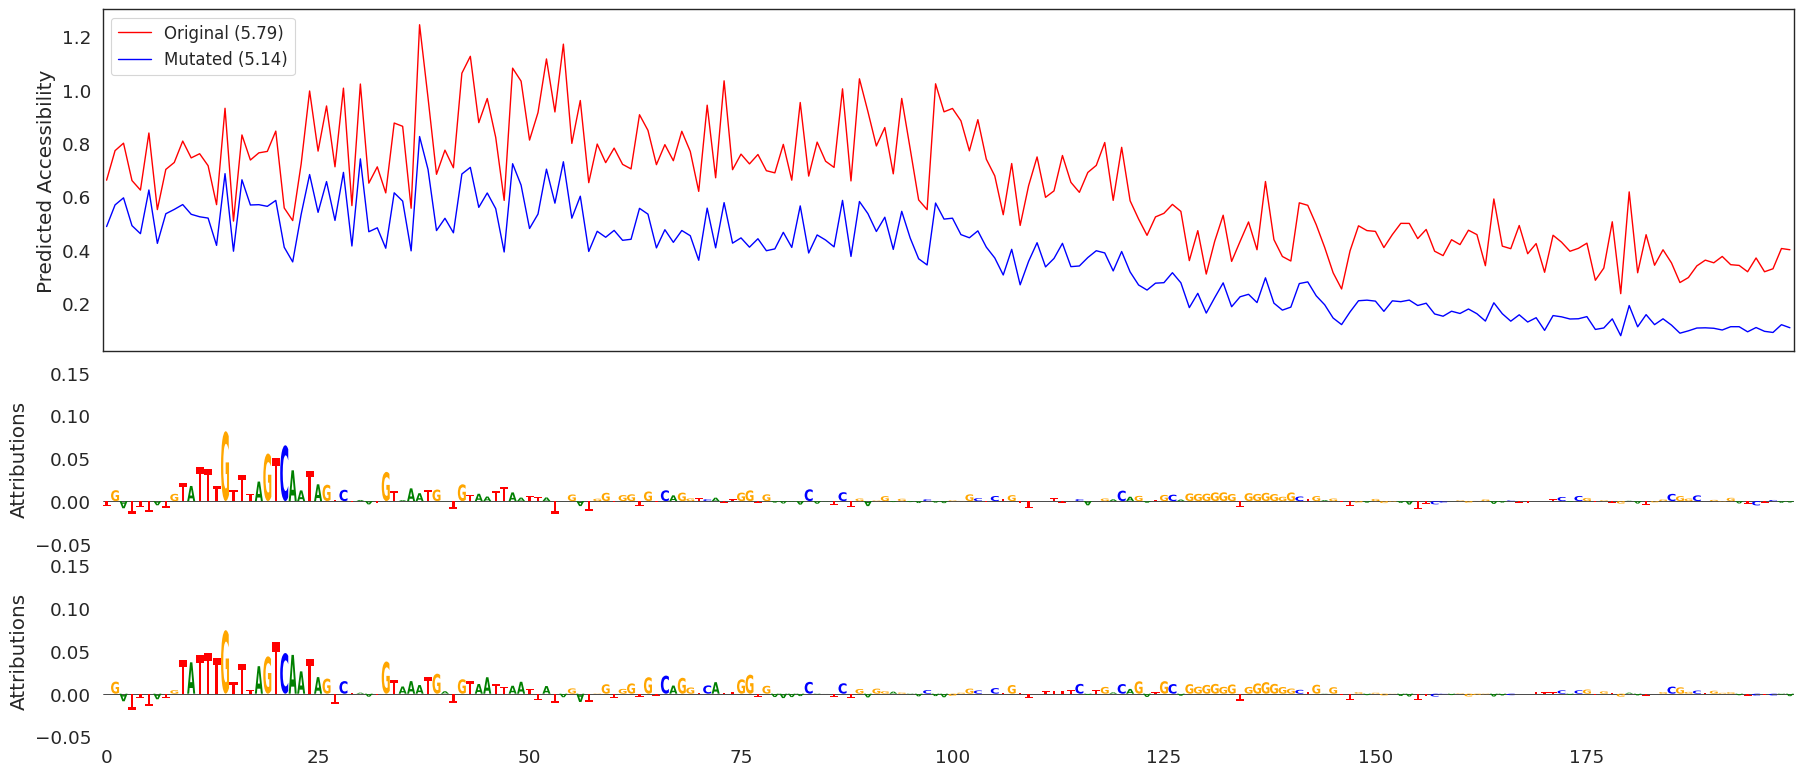

In [176]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [177]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [178]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,MEOX2_MA0706.1,954,968,0.029603,-1.332268e-15
1,FOXA2_HUMAN.H11MO.0.A,961,979,0.496386,1.739130e-02
2,HNF6_HUMAN.H11MO.0.B,939,953,0.236398,3.478261e-02


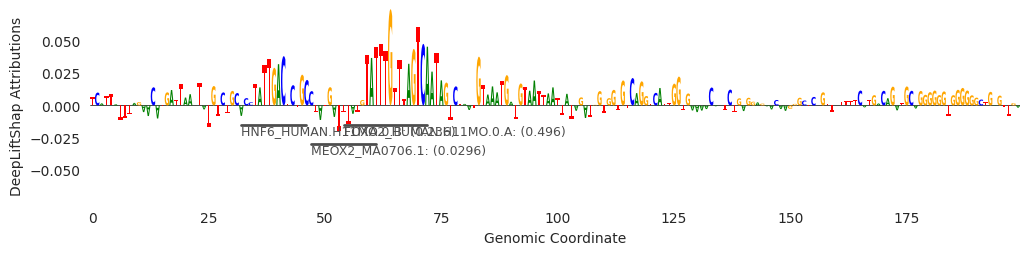

In [179]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

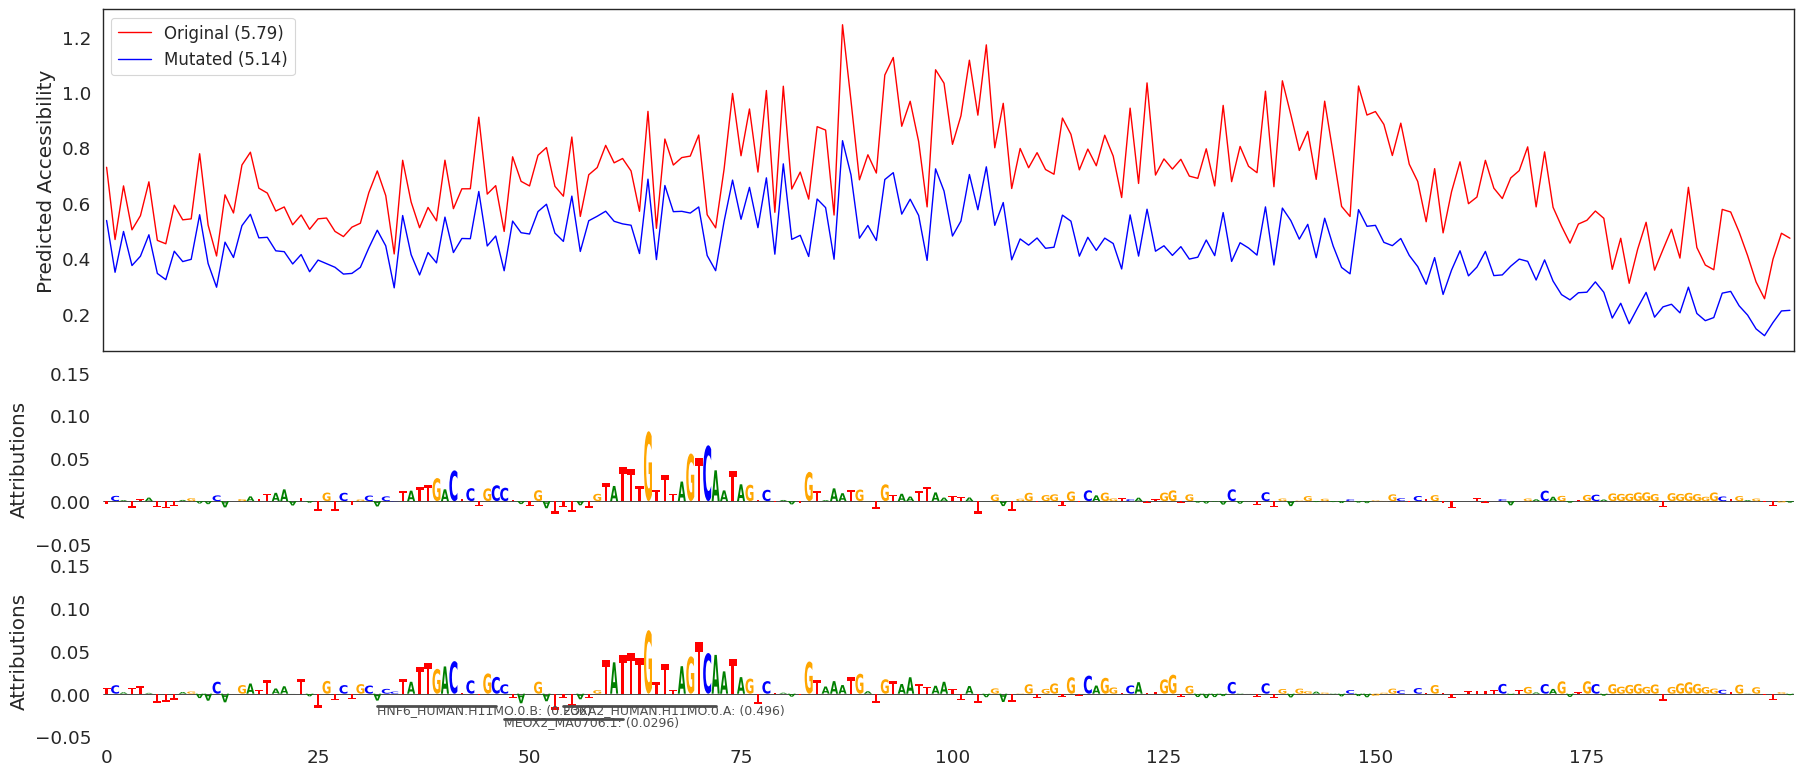

In [180]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f"NKX61_ism_min_1_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [181]:
kinda_minimize_preds = np.log(mutated_counts)

# Distribution of single mutations

In [145]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [146]:
X_ = torch.tensor(original_seq_onehot)

In [147]:
from tangermeme.ism import saturation_mutagenesis

In [148]:
# Run ISM
y0, y_hat = saturation_mutagenesis(
    count_wrapper,
    X_,
    start=seq_start,
    end=seq_end,
    raw_outputs=True,
    verbose=True,
)

 29%|██▊       | 18/63 [00:00<00:01, 30.10it/s]

100%|██████████| 63/63 [00:02<00:00, 30.58it/s]


In [149]:
# Optional mask
msk = (torch.abs(y_hat[:, :, :, 0] - y0[:, None, None, 0]) < 5e-4)
msk = msk.float()

In [150]:
attr = y_hat[:, :, :, 0] - y0[:, None, None, 0]
#attr = torch.exp(y_hat[:, :, :, 0]) - torch.exp(y0[:, None, None, 0])
attr = attr.numpy()

In [151]:
# Make all msk positions NaN
y_hat_np = y_hat[:, :, :, 0].cpu().numpy()
y_hat_np_msk = y_hat_np.copy()
y_hat_np_msk[msk.bool()] = np.nan

In [152]:
# Make a dataframe where x_axis is the position in the sequence and y-axis is forward_pred for y_hat_np[0] and reverse_pred for y_hat_np[1]
pred_df = pd.DataFrame(
    data=y_hat_np_msk.reshape(y_hat_np_msk.shape[0], -1).T, 
    columns=['preds']
)
pred_df.isna().sum(axis=0)

preds    12
dtype: int64

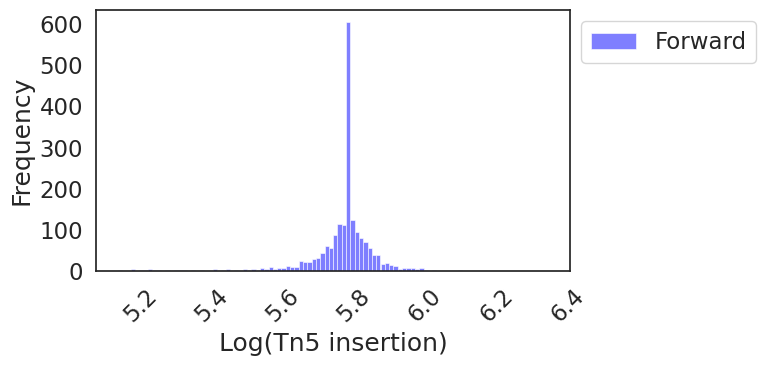

In [153]:
# Plot histograms of the forward predictions and the reverse predictions on same axis
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(data=pred_df, x='preds', color='blue', label='Forward', bins=100, ax=ax, alpha=0.5)

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

    plt.savefig(os.path.join(path_out, f"NKX61_ism_saturation_mutagenesis_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

# Plot all the mutations

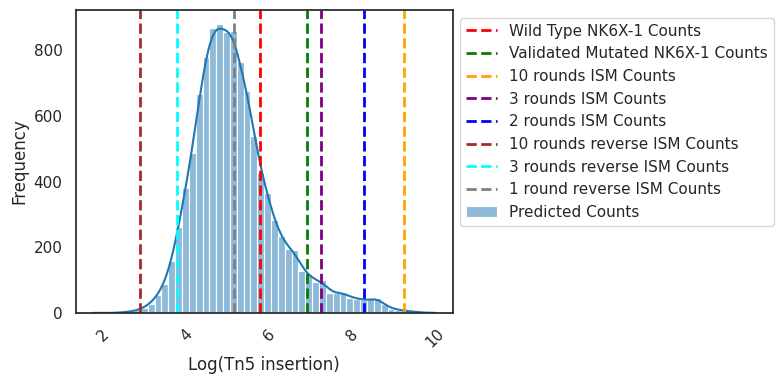

Exception ignored in atexit callback: <bound method InteractiveShell.atexit_operations of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x1555512f6cd0>>
Traceback (most recent call last):
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3952, in atexit_operations
    self._atexit_once()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3935, in _atexit_once
    self.history_manager.end_session()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/history.py", line 592, in end_session
    self.writeout_cache()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cellar/users/aklie/opt/miniconda3/envs/eug

In [ ]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        y_0,
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot NKX6-1 Enhancer Original as vertical line
    ax.axvline(x=wild_type_enhancer_counts, color='red', linestyle='--', linewidth=2, label='Wild Type NK6X-1 Counts')
    
    # Plot NKX6-1 Enhancer Mutated as vertical line
    ax.axvline(x=validated_mutated_enhancer_counts, color='green', linestyle='--', linewidth=2, label='Validated Mutated NK6X-1 Counts')

    # Plot the maximum counts as vertical line
    ax.axvline(x=maximum_counts, color='orange', linestyle='--', linewidth=2, label='10 rounds ISM Counts')

    # Plot the matched counts as vertical line
    ax.axvline(x=matched_preds, color='purple', linestyle='--', linewidth=2, label='3 rounds ISM Counts')

    # Plot the kinda maximized counts as vertical line
    ax.axvline(x=kinda_maximize_preds, color='blue', linestyle='--', linewidth=2, label='2 rounds ISM Counts')

    # Plot the minimized counts as vertical line
    ax.axvline(x=minimize_preds, color='brown', linestyle='--', linewidth=2, label='10 rounds reverse ISM Counts')
    
    # Plot the somewhat minimized counts as vertical line
    ax.axvline(x=somewhat_minimize_preds, color='cyan', linestyle='--', linewidth=2, label='3 rounds reverse ISM Counts')

    # Plot the kinda minimized counts as vertical line
    ax.axvline(x=kinda_minimize_preds, color='gray', linestyle='--', linewidth=2, label='1 round reverse ISM Counts')
    
    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

    plt.savefig(os.path.join(path_out, f"NKX61_ism_histogram_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

# DONE!

---